# W.02: The Poisson Distribution

\pagetab{W.02}

In [70]:
#! no-listings
# Import the numeric library for data handling
# and the matplotlib graphics library using
# the standard names
import matplotlib.pyplot as plot
import numpy as np
import scipy as sp
import pandas as panda
from matplotlib.ticker import (
    AutoMinorLocator,
    MultipleLocator,
)
from pandas import ExcelFile

# Import the statistics handling and plotting code
import statsmodels.graphics.gofplots as sm
import statsmodels.sandbox.distributions.extras as sm_extra

# Initialise the random number generator. This uses a seed to
# make the following script deterministic
randomiser = np.random.RandomState(1423)

In [71]:
#! no-listings
# Allow searching for file listings
import os.path

# Search for the 'fieldguide' style and 'fg_workshop' colour map. If these
# are not found, then it should default to the MatPlotLib defaults, which
# match the color sequence used in the FieldG Guides. Otherwise clear whatever
# style is in use, and use the styles as found
if os.path.isfile(
    "../../common/matplotlib/fieldguide.mplstyle"
):
    plot.style.use("default")
    plot.style.use(
        "../../common/matplotlib/fieldguide.mplstyle"
    )
if os.path.isfile(
    "../../common/matplotlib/workshops.mplstyle"
):
    plot.style.use(
        "../../common/matplotlib/workshops.mplstyle"
    )

# Define the core colour palette
signal_colours = {
    "yellow": "#f7ba0b",
    "orange": "#d4652f",
    "red": "#a02128",
    "violet": "#904684",
    "blue": "#154889",
    "green": "#317f43",
    "grey": "#9b9b9b",
    "brown": "#7b5141",
    "white": "#f4f4f4",
    "black": "#282828",
}

## Introduction

### Aim

Both _Workshops W.00_ (_The Uniform Distribution_) and _W.01_ (_The Normal Distribution_) introduced distributions which are largely concerned with modelling _things_. We have discussed the use of distributions to model _probabilities_: especially in _W.01_ where we looked at use of the CDF for the normal distribution in some detail. The third distribution, and the topic of this workshop focuses exclusively on probability modelling: the Poisson distribution.

The Poisson distribution also differs from the uniform and the normal distribution in that it _only_ has a discrete form. That is the Poisson distribution is a _discrete probability distribution_. For many fields, simulation of processes can be built from a series of _events_ linking _inputs_ to _outputs_ at discrete time intervals. This technique is called _discrete event simulation_ (DES) [@DiscreteEventSimulationHealthcare:2022], and underpins industrial tools such as FlexSim [@NewTechnologiesEducational:2024]. Not all distributions used in DES follow a Poisson distribution^[And indeed the next _Workshop_, _W.03_, introduces the exponential distribution, which builds on the Poisson distribution studied here.], but the discrete nature of the distribution both fits the underlying nature of DES, and provides tools to easily model common scenarios. For example a Poisson distribution would be a valid model for the number of calls arriving at a call centre, assuming all calls are independent. In networking engineering, the Poisson distribution is also often using to model packet arrival times or other discrete events.

### Learning Outcomes

* To understand the definition of the Poisson distribution, and how this definition can be used in NumPy and SciPy 
* To quickly plot multiple datasets or distributions on charts in Matplotlib
* To apply your understanding to model simple probabilities using a Poisson distribution


## Defining the Poisson Distribution

The Poisson distribution is a discrete probability distribution for *independent* events. The distribution expresses the probability of a given number of events occurring in a fixed interval of time if these events occur with a known constant mean rate^[*Note* 'time' could be another interval type (with a dimension greater than 1) such as number of events in a given area or volume. The main criteria is that events are independent of each other.]. It is defined by its constant mean rate, $\lambda$, which is also the value of the variance, at the quantile $k$. The probability mass function and cumulative distribution functions are given in [@tbl:W02_PoissonDef].

| **Term** | **Expression**                                                                                                                   |
|----------|----------------------------------------------------------------------------------------------------------------------------------|
| Mean     | $\lambda$                                                                                                           |
| Variance\vspace{1em} | $\lambda$                                                                                                   |
| Probability Mass Function (PMF)\vspace{5em}      | $\begin{aligned}f(k; \lambda) &= P(X=k)\\ &= \dfrac{\lambda^ke^{-k}}{k!}\end{aligned}$ \break\vspace{0.75em}\break $\text{for } k \in \{0, 1, 2, ...\} \text{ and }\lambda \in (0, \infty)$          |
| Cumulative Distribution Function (CDF)\vspace{5em}     | $\begin{aligned} F(k; \lambda) &= e^{-\lambda}\sum_{n=0}^{\lfloor k \rfloor} \dfrac{\lambda^n}{n!}\\ &=\dfrac{\Gamma({\lfloor k + 1\rfloor}, \lambda)}{k!}\\ &= \dfrac{1}{\Gamma({\lfloor k \rfloor}+1)}\int_\lambda^\infty t^{{\lfloor k \rfloor}}e^{-t} dt\end{aligned}$ \break\vspace{0.75em}\break where $\Gamma(x, y)$ is the upper incomplete Gamma function, and $\lfloor k \rfloor$ is the floor function. |

Table: Definitions of the Poisson Distribution {#tbl:W02_PoissonDef}

The Poisson distribution is a generalisation of the binomial distribution which is defined as 

$$P(X=r) = {}^{n}C_r(1-p)^{n-r}p^r$$ 

where 

- $r$ is number of successes
- $n$ is number of trials and 
- $p$ is probability of success

For large values of $n$ with small values of $p$ we can use the Poisson distribution with $\lambda = np$ as an approximation.

## The Poisson Distribution in SciPy

### Plotting the PMF and CDF

#### Using the Standard Method Calls

In `scipy.stats` the [`scipy.stats.poisson`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sp.stats.poisson.html#scipy.stats.poisson) class defines the Poisson distribution, using the same interface we have used previously. 

Both the PMF and CDF are defined at the quantile `k`, with the mean `mu`, and the location `loc`. The core method prototypes are therefore `scipy.stats.poisson.pmf(k, mu, loc)`, or `scipy.stats.poisson.cdf(k, mu, loc)`.

By default for both the `pmf()` and `cdf()` methods the third parameter, `loc`, has the value `loc = 0`. The `loc` parameter effectively shifts the standardised Poisson from the mean at `k` for both the PMF and CDF. Both methods can therefore also be called as 

* `scipy.stats.poisson.pmf(k - loc, mu)`, or 
* `scipy.stats.poisson.cdf(k - loc, mu)`

For our plots and examples, we will set $\lambda = 2$, and leave the `loc` at the default (`0`), for the subsequent calls^[In Python 3, '`lambda`' is now a reserved word for anonymous functions. So the variable used here (and in later calls) will be called '`p_lambda`' for the mean, $\lambda$.]

In [72]:
p_lambda = 2

Using the `stats()` method, and with the standard arguments for mean and variance, we then obtain the following values. Unlike previous distributions, however, for the Poisson distribution only have to set the mean, `p_lambda`, to obtain the correct distribution

In [73]:
mean, var = sp.stats.poisson.stats(p_lambda, moments="mv")

print(f"\nMean: {mean:.2f}\n" f"Variance: {var:.2f}\n")


Mean: 2.00
Variance: 2.00



Note the variance and the mean are the same, as defined in [@tbl:W02_PoissonDef]. 

We will now plot the PMF and CDF for different quantiles, which follows essentially the same process as we have used before. Therefore we will only briefly cover the necessary Python code, and concentrate on the output from the PMF and CDF distributions.

First we will define the range of quantiles to plot, from 0 to 10 in integer steps

In [74]:
quantiles = np.arange(0, 11, 1)

The PMF can then be plotted in [@fig:W02_PoissionPMF1] for each quantile in `quantiles`, using the mean `p_lambda`, as follows. The only difference between previous plots in _Workshops W.00_ (_The Uniform Distribution_) and _W.01_ (_The Normal Distribution_) is the call to [`scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) (instead of `plot()`) in `Line 28`. This creates a _scatter plot_, where each quantile, $x$, and PMF value, $y$ is plotted separately. As with other PMF values, the output of the Poisson PMF is _discrete_ and so the values are _not_ connected. We can, though, still see the shape of the PMF in [@fig:W02_PoissionPMF1].

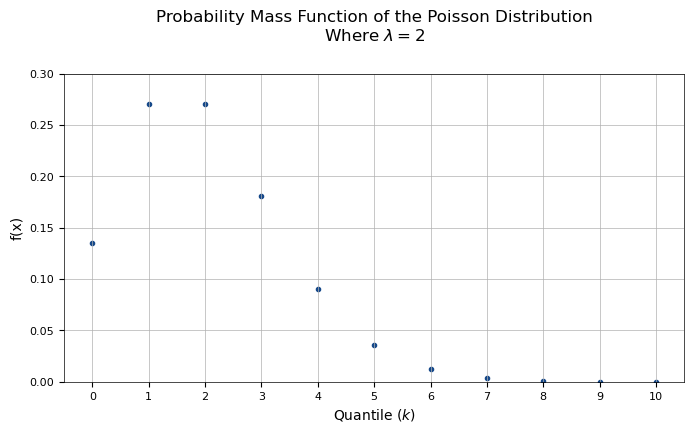

In [75]:
# A Scatter Plot of the Poisson PMF where $\lambda = 2$
# For the Quantiles $k = 1, 2, \dots,20$
# fig:W02_PoissionPMF1

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")
plot.xticks(quantiles)

# Label the axes
plot.xlabel("Quantile ($k$)")
plot.ylabel("f(x)")

# Label the plot
plot.title(
    "Probability Mass Function of the Poisson Distribution\n"
    "Where $\\lambda = $" + str(p_lambda),
    pad=24.0,
)

# Set the axis limits
plot.ylim(0, 0.3)

# Display the graph
plot.scatter(
    quantiles, sp.stats.poisson.pmf(quantiles, p_lambda)
)

Plotting the CDF in [@fig:W02_PoissionCDF1] is essentially identical, apart from the method call in `Line 28`. Again we are also using a scatter plot for [@fig:W02_PoissionCDF1], to show the values of the CDF are distinct.

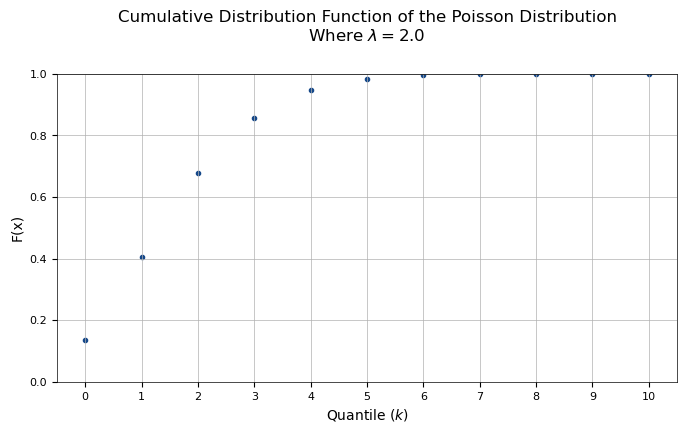

In [76]:
# The Plot of the Poisson CDF where $\lambda = 20$
# For the Quantiles $k = 1, 2, \dots,20$
# fig:W02_PoissionCDF1

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")
plot.xticks(quantiles)

# Label the axes
plot.xlabel("Quantile ($k$)")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Cumulative Distribution Function of the Poisson Distribution\n"
    "Where $\\lambda = $" + str(mean),
    pad=24.0,
)

# Set the axis limits
plot.ylim(0, 1.0)

# Display the graph
plot.scatter(
    quantiles, sp.stats.poisson.cdf(quantiles, p_lambda)
)

#### Plotting Multiple Poisson Distributions

To compare the distributions of different Poisson curves at different means, we will use an adaptation of techniques you have seen in _Workshops W.00_ (_The Uniform Distribution_) and _W.01_ (_The Normal Distribution_). In _Workshop W.00_ we used successive calls to `plot.plot()` when adding multiple curves to a single figure. Whereas in _Workshop W.01_ we introduced the method call to  `plot.subplots()` to break up the display of quantiles into four separate sub-figures.

For the comparison of mean values, we will use 'sub-figures': but this time combine all the curves into a single figure. This technique is useful when you don't know quite how many curves you want to combine on a single plot, as we can add each curve programmatically.

We will start with an array of mean values we want to plot curves for

In [77]:
# generating PMF for different means
means = [0.5, 1, 2.25, 4]

We will now use `plot.subplots` as we did for _Workshop W.01_, but this time we will set the rows and columns to '`1`' in `Line 5`. This will force the generation of a single figure, instead of the multiple sub-figures we had last time. We will then walk the `means` array, creating a new plot via a call to `subfig.plot()` in `Line 8` to `Line 13`. We are also re-using the `quantiles` array we set-up before, and similarly using the call to `poisson.pmf()` to generate the curve at the specified `mean` value. 

The rest of the code is much the same as last time. The main different is the use of a [_format string_](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html), '`o:`', in the calls to `subfig.plot()`. Format strings allow you to compactly specify the marker type, colour and the connecting line format as a single string. In this case it represents a circle marker ('`o`'), connected by a dotted line-style ('`:`')^[The Matplotlib [cheatsheets](https://matplotlib.org/cheatsheets/) also provide a useful summary of available options, outside the official documentation.]. We have left Matplotlib to pick the colour from the current [colour cycler](https://matplotlib.org/stable/users/explain/artists/color_cycle.html), so that we automatically get a different colour for each call. The final result should be in [@fig:W02_PoissionPMF2].

Text(0.02, 0.5, 'f(x)')

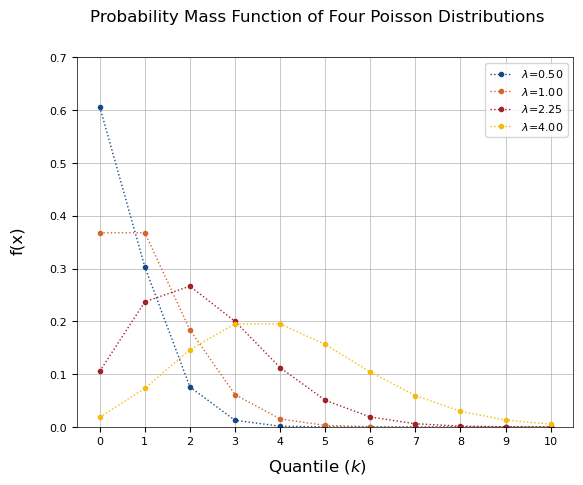

In [78]:
# Plot of the PMF Values of the Quantiles for Four Poisson
# Distributions
# fig:W02_PoissionPMF2

figure, subfig = plot.subplots(ncols=1, nrows=1)

for index in range(4):
    subfig.plot(
        quantiles,
        sp.stats.poisson.pmf(quantiles, means[index]),
        "o:",
        label=f"$\\lambda$={means[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.legend(loc="best")

subfig.set_xticks(quantiles)

# Set the axis limits
subfig.set_ylim(0, 0.7)

# Label the plot
figure.suptitle(
    "Probability Mass Function of Four Poisson Distributions\n",
)

# Label the axes
figure.supxlabel("Quantile ($k$)")
figure.supylabel("f(x)")

Exactly the same techniques can then be used in [@fig:W02_PoissionCDF2] to draw the equivalent CDF 'curve' for each of the mean values. Note that in both [@fig:W02_PoissionPMF2] and [@fig:W02_PoissionCDF2] the lines are to help with visualisation --- they do _not_ mean a continuous curve. The discrete values indicated by the circles are the actual values

Compared to the PMF of the uniform and normal distributions, the PMF for the Poisson distribution in [@fig:W02_PoissionPMF2] shows distinct variations for different values of $\lambda$. For integer values of the mean ($\lambda = 1$ and $\lambda = 4$), we get two maximum values of the PMF at $\lambda$. You can also see this behaviour in [@fig:W02_PoissionCDF2]. Whereas the non integer values of $\lambda$ result in a peak at one value.

Text(0.02, 0.5, 'F(x)')

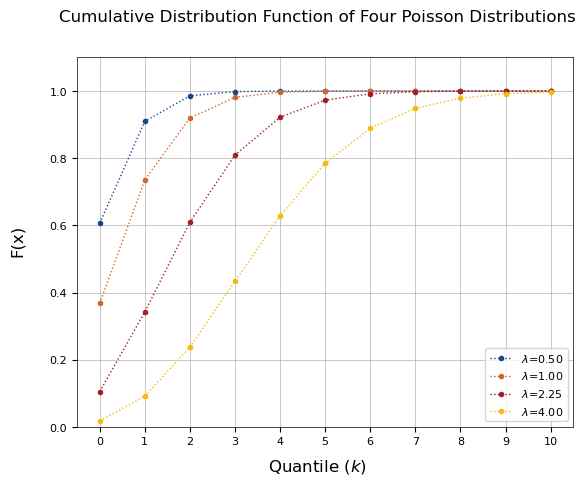

In [79]:
# Plot of the CDF Values of the Quantiles for Four Poisson
# Distributions
# fig:W02_PoissionCDF2

figure, subfig = plot.subplots(1, 1)

for index in range(4):
    subfig.plot(
        quantiles,
        sp.stats.poisson.cdf(quantiles, means[index]),
        "o:",
        label=f"$\\lambda$={means[index]:.2f}",
    )

# Format the plot
subfig.grid(True, which="both")
subfig.legend(loc="best")

subfig.set_xticks(quantiles)

# Set the axis limits
subfig.set_ylim(0, 1.1)

# Label the plot
figure.suptitle(
    "Cumulative Distribution Function of Four Poisson "
    "Distributions\n",
)

# Label the axes
figure.supxlabel("Quantile ($k$)")
figure.supylabel("F(x)")

### Extra Mile: Exploring PMFs and CDFs

You can explore more of the shape of both the PMF and CDF curves for the Poisson distribution by creating an interactive version of [@fig:W02_PoissionPMF1] and [@fig:W02_PoissionCDF1]. Use the code we looked at in _W.01_ (_The Normal Distribution_), and adapt it to use the Poisson distribution instead. This should help you explore the behaviour of the Poisson distribution at fractional values of $\lambda$ more easily.

## Quantiles: Using the Poisson Distribution

### Determining Single Event Probabilities

The main use for the Poisson distribution is to estimate probabilities where a mean (constant) rate, $\lambda$, exists for a specific event. This use stems from the earlier definition of the Poisson distribution.

For example, imagine you are trying to work out whether to build a flood defence system. You would want to know whether the cost of building the defences outweighs the potential loss in allowing the river to flood. If the river only rarely floods, the cost of the flood defence is unlikely to be viable. So for our example we will say the river floods twice every 100 years. This gives a mean constant rate of flooding of $\lambda = 2$ for that 100 year period.



In [80]:
# Mean rate of flooding in a 100 year period
p_lambda = 2

Using the PMF of a Poisson distribution allows us to estimate probabilities at a _specific_ quantile ($k$), for that given mean rate $\lambda$. For instance if we want to know the probability the river _won't_ flood in the 100 year period we would want to evaluate the PMF at $P(k = 0)$

In [81]:
print(f"Probability of no floods:\
    {sp.stats.poisson.pmf(0, p_lambda): .3f}\n")

Probability of no floods:     0.135



Similarly to work out the probability of exactly three floods, $P(k = 3)$, we would use

In [82]:
print(f"Probability of three floods:\
    {sp.stats.poisson.pmf(3, p_lambda): .3f}\n")

Probability of three floods:     0.180



You should be able to estimate these values from [@fig:W02_PoissionCDF1]. And also from [@fig:W02_PoissionCDF1] we know the probabilities of one, $P(k = 1)$, or two flooding events, $P(k = 2)$, will lie above these probabilities

In [83]:
print(f"Probability of one flood: \
    {sp.stats.poisson.pmf(1, p_lambda): .3f}")
print(f"Probability of two floods:\
    {sp.stats.poisson.pmf(2, p_lambda): .3f}\n")

Probability of one flood:      0.271
Probability of two floods:     0.271



### Determining Multiple Event Probabilities

Just as we use the PMF for single event probabilities, the CDF of the Poisson distribution can be used for _multiple_ event probabilities. Staying with the same example (so $\lambda = 2$), we can use the CDF in [@fig:W02_PoissionCDF1] as follows.

Estimating probabilities _below_ a quantile value $k$ means summing from $0$ to $k$. This is straightforward application of the CDF. For example to determine the probability of fewer than three flooding events we need to evaluate $P(k \leq 3)$

In [84]:
print(f"Probability of 3 floods or fewer:\
    {sp.stats.poisson.cdf(3, p_lambda): .3f}\n")

Probability of 3 floods or fewer:     0.857



Estimating probabilities _above_ a specific quantile value requires finding the probability that is _not_ below the required quantile. The easiest way to do that is to subtract the probability estimation on the CDF from $1$. 

For example to estimate the probability of more than four floods, $P(k > 4)$, we would use 

In [85]:
print(f"Probability of more than 4 floods:\
    {1-sp.stats.poisson.cdf(4, p_lambda): .3f}\n")

Probability of more than 4 floods:     0.053



### Determining Probability Ranges

Finding the range of probabilities for specific events may require using both the PMF and CDF, depending on the range of interest. For example if we are interested in knowing the probabilities of _exactly_ 1 or 2 floods, $P(k \in \{1,2\})$ , we need both $P(k = 1)$ and $P(k = 2)$. The overall probability is then

$$P(k \in \{1,2\}) = P(k = 1) + P(k = 2)$$

In Python, this looks like

In [86]:
print(f"Probability of 1 or 2 floods:\
    {sp.stats.poisson.pmf(1, p_lambda) + 
    sp.stats.poisson.pmf(2, p_lambda): .3f}")

Probability of 1 or 2 floods:     0.541


Creative use of the python [`range()`](https://docs.python.org/3/library/stdtypes.html#range) method can also help for more complex calculations. For example to estimate $P(k \in \{1,2,3\})$ we could use^[Note that `range()` computes the interval $[[\text{start}, \text{stop}))$, so we are using a `stop` value of `4`, not `3` here.]

In [87]:
p_total = 0
for p in range(1, 4):
    p_total += sp.stats.poisson.pmf(p, p_lambda)

print(f"Probability of 1 to 3 floods: {p_total: .3f}")

Probability of 1 to 3 floods:  0.722


To estimate those probabilities we use quantiles in the same way we did for the normal distribution in _W.01_ (_The Normal Distribution_). We can either estimate the probability at a specific value, using the

 or we can estimate 

Given on average a river overflow floods twice every 100 years, calculate, to 4 d.p., the probability that:

>* There are no floods in 100 years $P(k=0)$
>* There are 3 or less floods in 100 years  $P(k \leq 3)$
>* There are more than 4 floods in 100 years $P(k > 4)$
>* THere are 1 or 2 floods in 100 years $P(k \in \{1,2\})$

### Finding the Mean Rate

In the previous example, determining the constant mean rate is relatively straightforward. However in some cases we have to do a bit of work to determine what $\lambda$ should be. For example in the following example we have two probabilities to consider

>On average, the probability of a integrated circuit chip being defective is 0.001. Given a batch of 800 chips what is the probability that:
>
>* none are defective, $P_1(k=0)$
>* less than 2 are defective, $P_2(k<2)$
>* at least 4 are defective, $P_3(k\geq 4)$
>* 1, 2 or 3 chips are defective, $P_4(k \in \{1,2,3\})$

However, the important assumption is that the _error probability_, $P_\text{error}$, is constant. So too is the batch size at 800. This means the error probability within each batch is also constant

$$\begin{aligned}
P_\text{batch error} &= P_\text{error} \times 800\\
 &= 0.001 * 800\\
 &= 0.8
\end{aligned}$$

_As long as the overall rate is constant, the Poisson distribution will work_. In the example above, if $P_\text{error}$ changes, or the batch size changes we will need a _different_ Poisson distribution. And if the error rate or batch sizes is constantly changing, the Poisson distribution may not be applicable at all.

Assuming, though, the assumptions do apply, we can make the probability estimates as follows

In [88]:
# mean
p_lambda = 800 * 0.001

# using PMF to calculate fixed value
p1 = sp.stats.poisson.pmf(0, p_lambda)

# Using CDF to calculate less than or at least
p2 = sp.stats.poisson.cdf(1, p_lambda)
p3 = 1 - sp.stats.poisson.cdf(3, p_lambda)

# Use PMFs and sum for set of values
p4 = 0
for p in range(1, 4):
    p4 += sp.stats.poisson.pmf(p, p_lambda)

print(
    f"Probability of no defective chips:\t\t{p1: .3f}\n"
    f"Probability of less than 2 defective chips:\t{p2: .3f}\n"
    f"Probability of at least 4 defective chips:\t{p3: .3f}\n"
    f"Probability of 1, 2 or 3 defective chips:\t{p4: .3f}\n"
)

Probability of no defective chips:		 0.449
Probability of less than 2 defective chips:	 0.809
Probability of at least 4 defective chips:	 0.009
Probability of 1, 2 or 3 defective chips:	 0.542



\clearpage

## Questions

Use Python to answer the following questions. Where appropriate give answers to 4 decimal places.



1. On average 4 vehicles arrive at a junction with traffic lights during the cycle of the lights. What is the probability:

    a. Exactly 5 vehicles arrive in a cycle $P(k=5)$  
    b. Less than 4 vehicles arrive in a cycle $P(k < 5)$)  
    c. If the cycle allows only 5 vehicles through, what is the probability that all the waiting vehicles are not cleared in a cycle $P(k > 5)$  


*Answer*:

In [89]:
# code for question 1(a) -- 1(c)

2. On average 3 calls per minute arrive at a call centre. What is the probability:

    a. 1 call arrives in a minute?  
    b. Less than 3 calls arrive in a minute?  
    c. 4 or more calls arrive in a minute?  
    d. The number of calls that arrive is 2, 3 or 4? 

*Answer:*

In [90]:
# code for question 2(a) -- 2(d)

3. Results show that 1 in 1000 transistors are defective on average. What is the probability that:

    a. There are no defective transistors in a batch of 750?  
    b. There are 4 defective transistors in a batch of 2000?  
    c. There are less than 5 defective transistors in a batch of 2500?  
    d. There are 3 or more defective transistors in a batch of 1000?  
    e. There is 1 or 2 defective transistors in a batch of 2000?  


In [ ]:
# code for question 3(a) -- 3(e)

4. On average a machine can process 4 packages in a minute. What is the probability that:

    a. In 10 minutes the process processes 45 packages?  
    b. In 5 minutes 18 or fewer packages are processed?  
    c. In 15 minutes between 55 and 65 packages are processed?  
    d. In an hour at least 250 packages are processed?  
    e. In an hour the number of packages processed is between 235 and 245?  

*Answer*:

In [ ]:
# code for question 4(a) -- 4(e)

## References